In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import sys
sys.path.append('/nird/projects/NS9873K/emile/unseen-storm-forecasts')

import xarray as xr
import numpy as np

In [2]:
import test_fidelity as fid
import test_independence as ind
import test_stability as stab

Checking raw data tests

In [3]:
processed = xr.open_dataarray("processed-july.nc")
maxs = xr.open_dataarray("maxs-july.nc")

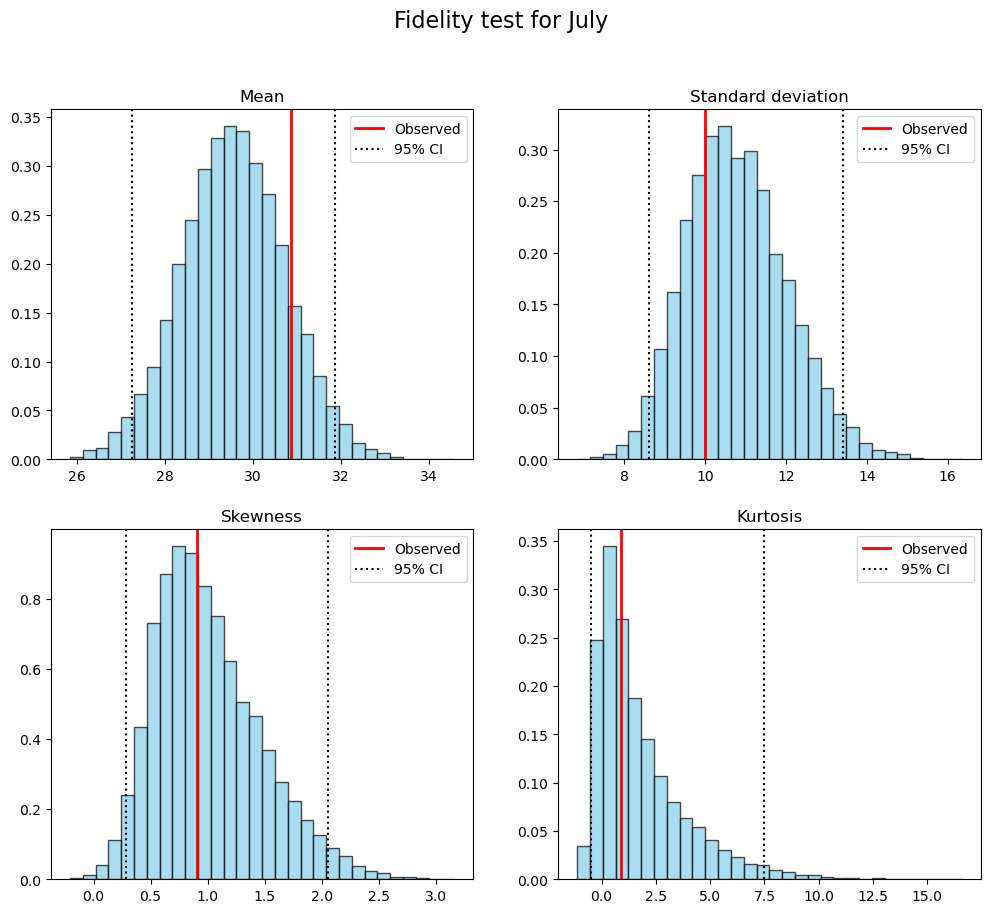

In [5]:
rea, mod = fid.main("maxs-july.nc", "../../data/processed-rea.nc")
fid.plot(rea, mod, "raw", "July", show=True)

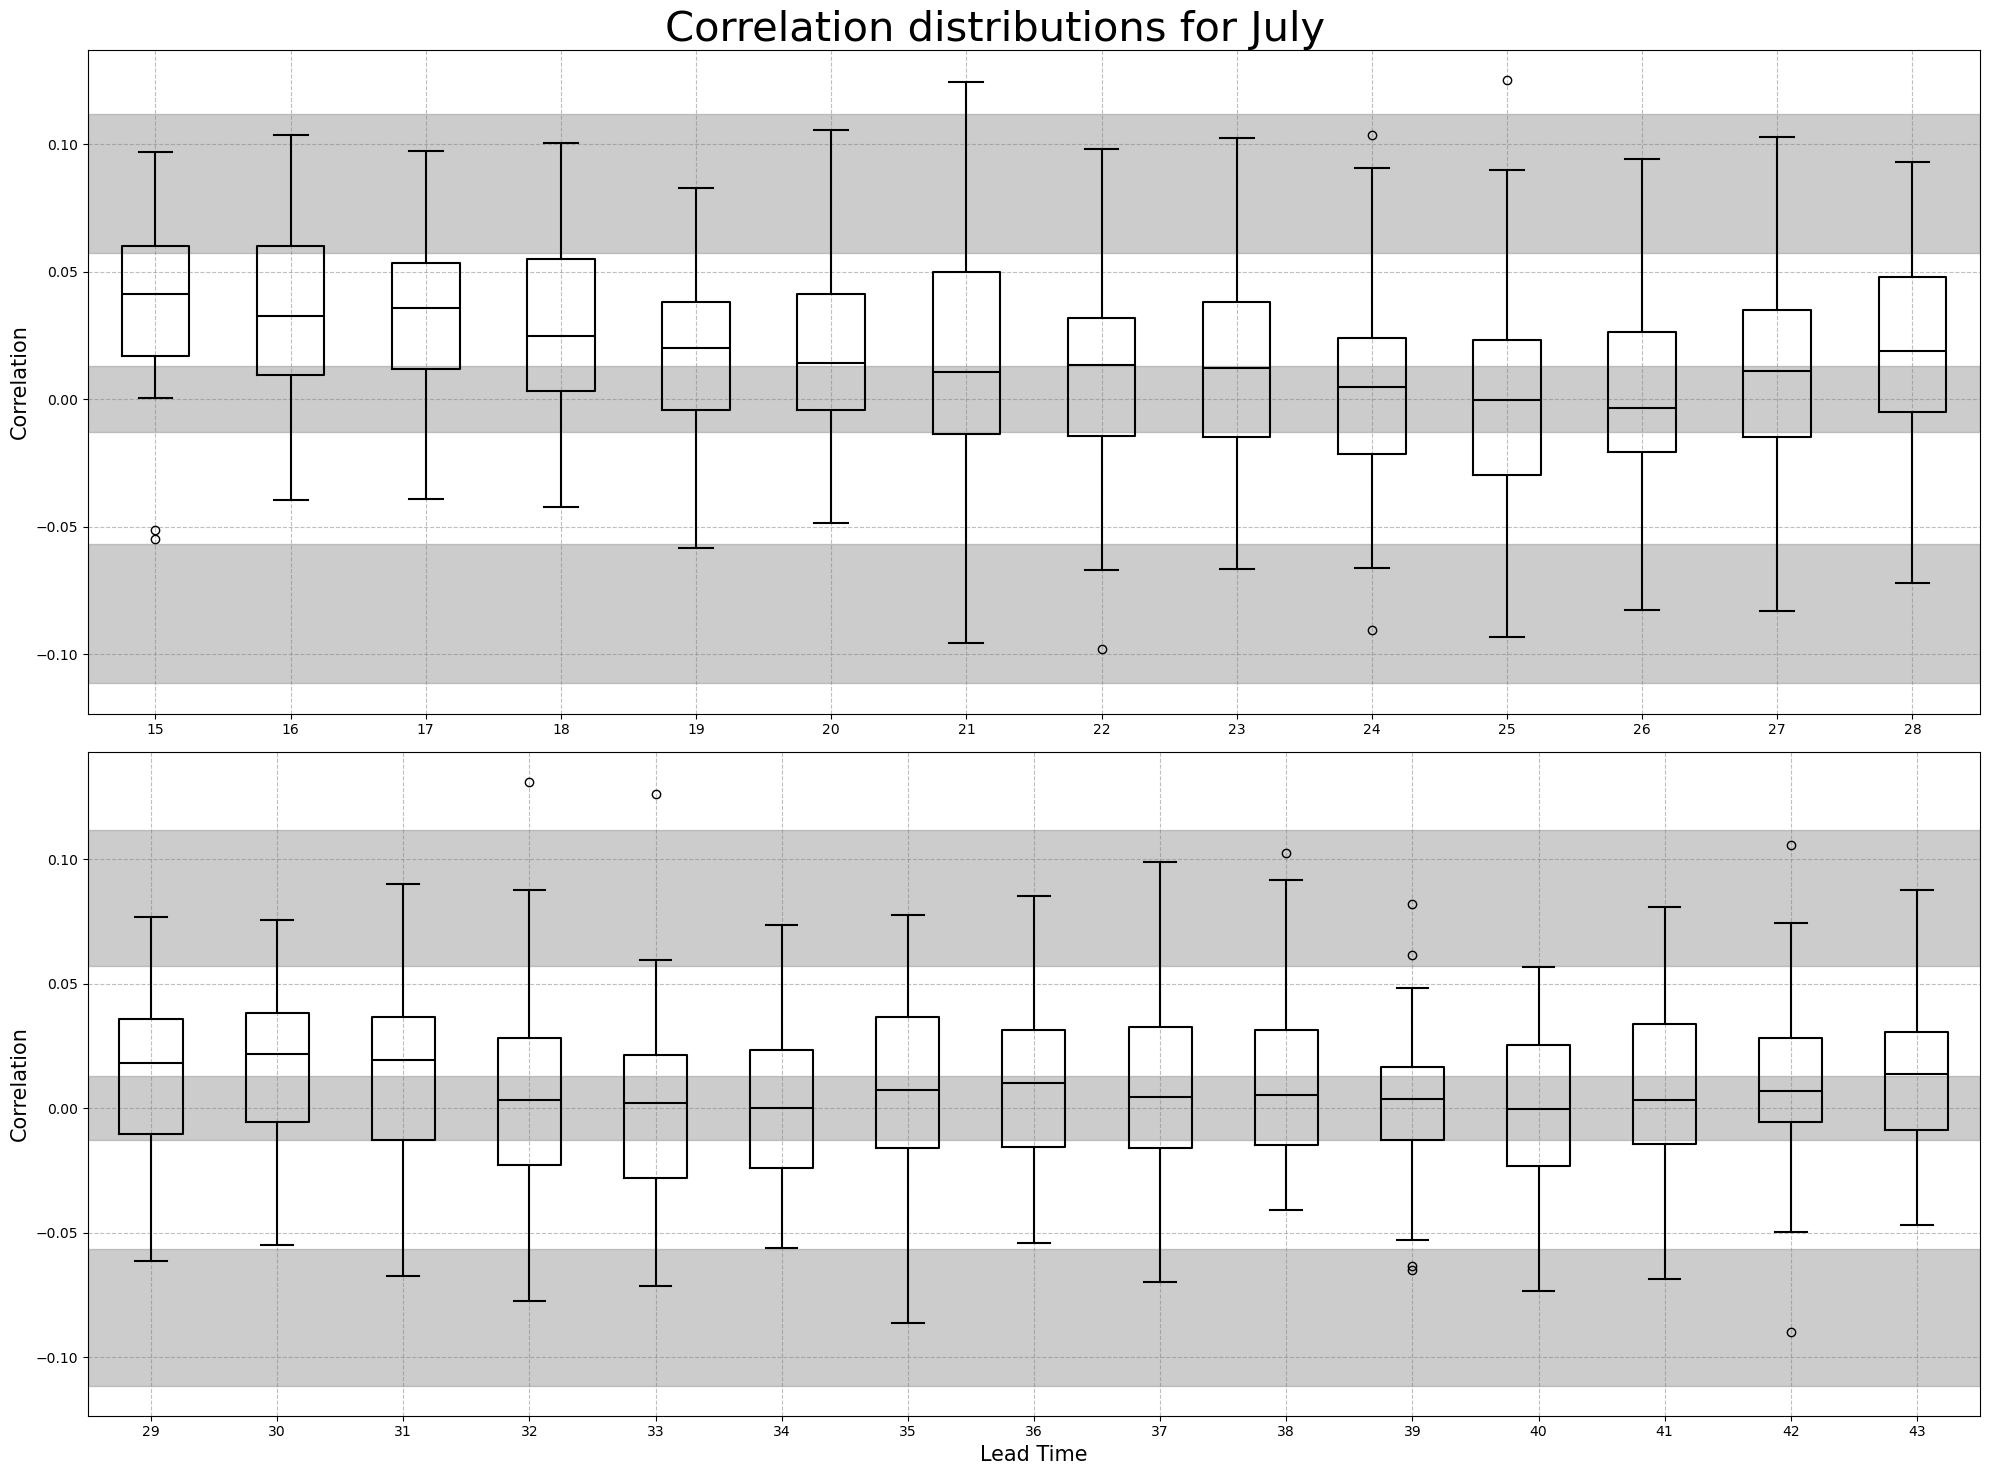

In [6]:
corr, interv = ind.correlation(processed)
ind.plot_correlations(corr, interv, "raw",show=True)

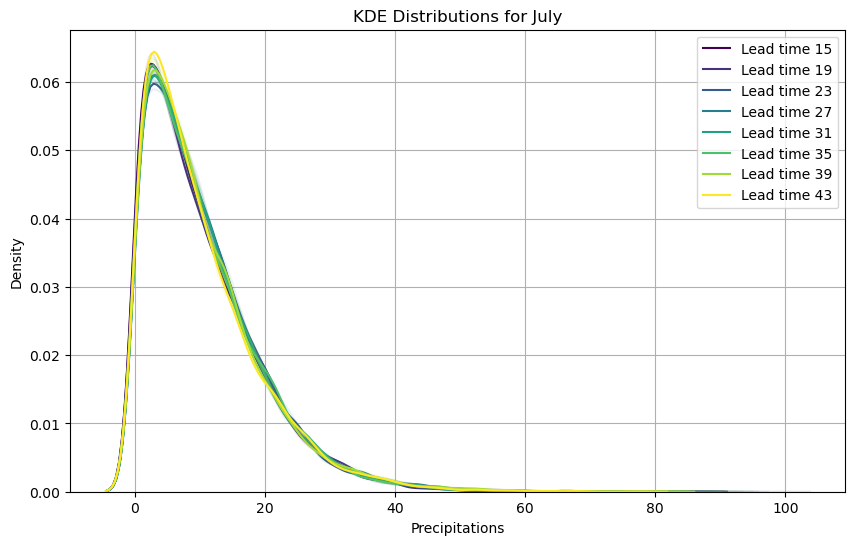

In [7]:
stab.plot_kde_distributions(processed, "raw", show=True)

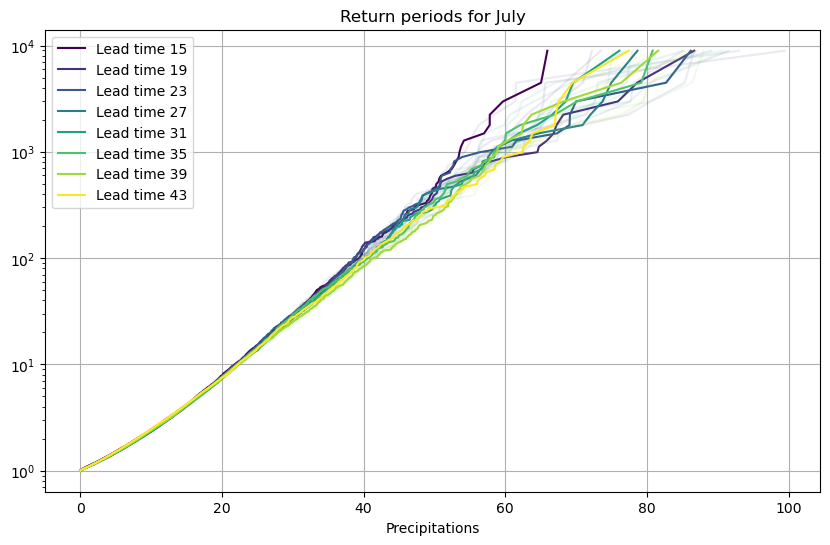

In [8]:
stab.plot_return_period(processed, "raw", show=True)

### Correcting independence

We remove the first 5 values

In [9]:
corrected_1 = processed[...,5:]
maxs_corrected_1 = corrected_1.max(dim="time")

In [10]:
corrected_1.to_netcdf("corrected_1.nc")
maxs_corrected_1.to_netcdf("maxs_corrected_1.nc")

### Fidelity correction

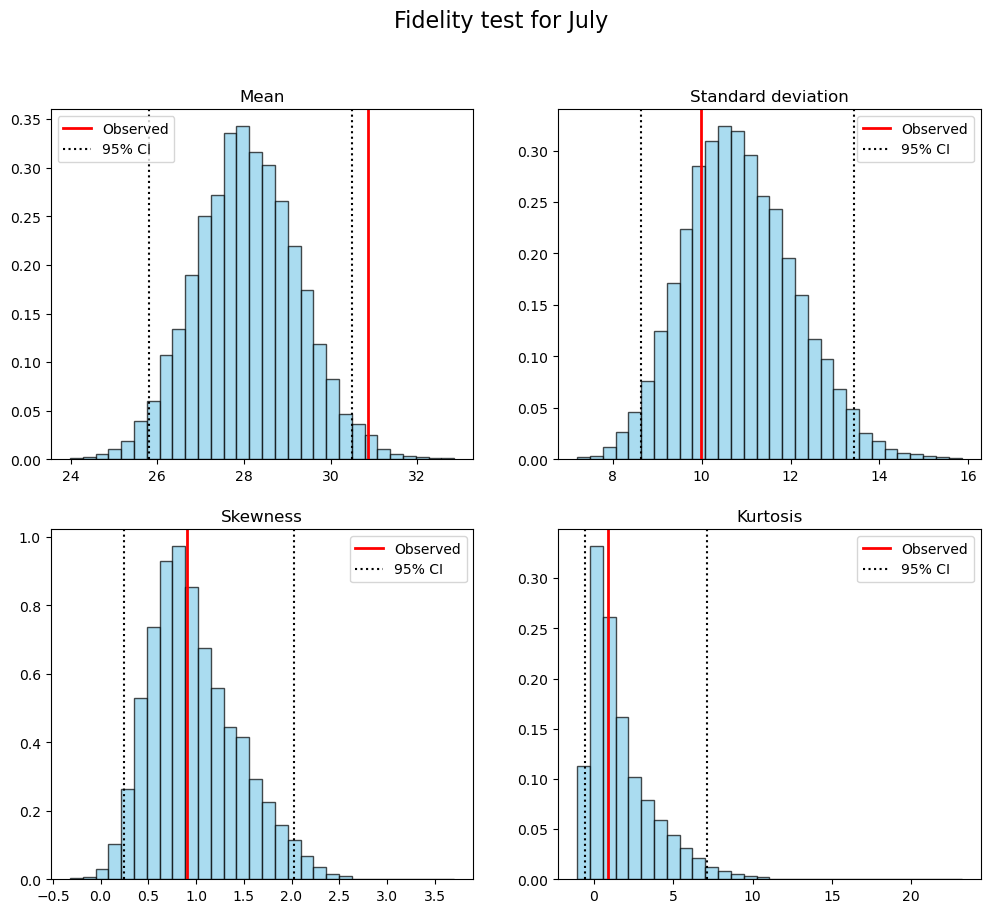

In [15]:
rea, mod = fid.main(
    "maxs_corrected_1.nc", "../../data/processed-rea.nc"
)
fid.plot(rea, mod, "", "July", show=True)

In [16]:
maxs_corrected_2 = maxs_corrected_1 + 3
corrected_2 = corrected_1 + 3

In [17]:
corrected_2.to_netcdf("corrected_2.nc")
maxs_corrected_2.to_netcdf("maxs_corrected_2.nc")

### Final test

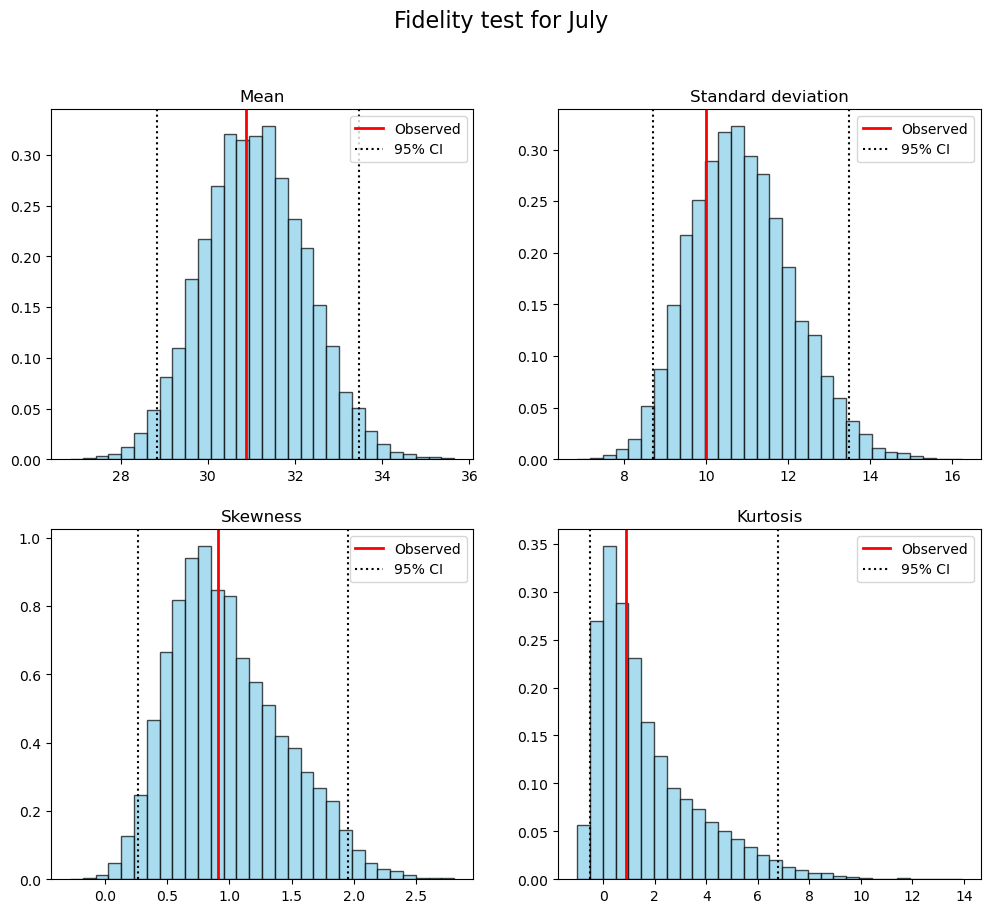

In [18]:
rea, mod = fid.main(
    "maxs_corrected_2.nc", "../../data/processed-rea.nc"
)
fid.plot(rea, mod, "", "July", show=True)

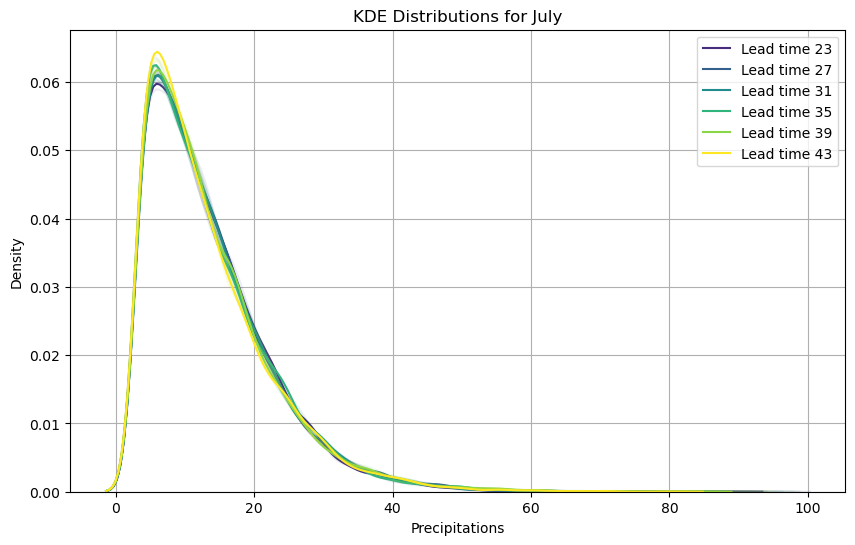

In [19]:
stab.plot_kde_distributions(
    corrected_2, "", show=True
)

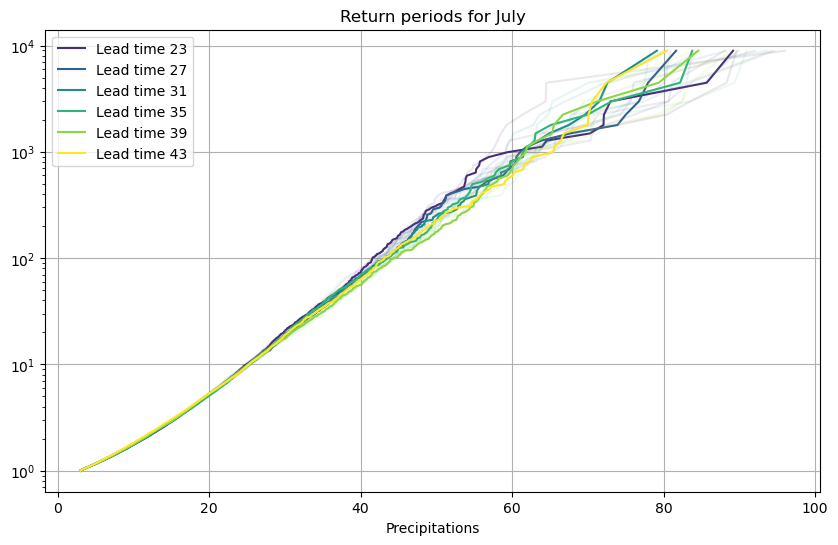

In [20]:
stab.plot_return_period(
    corrected_2, "", show=True
)

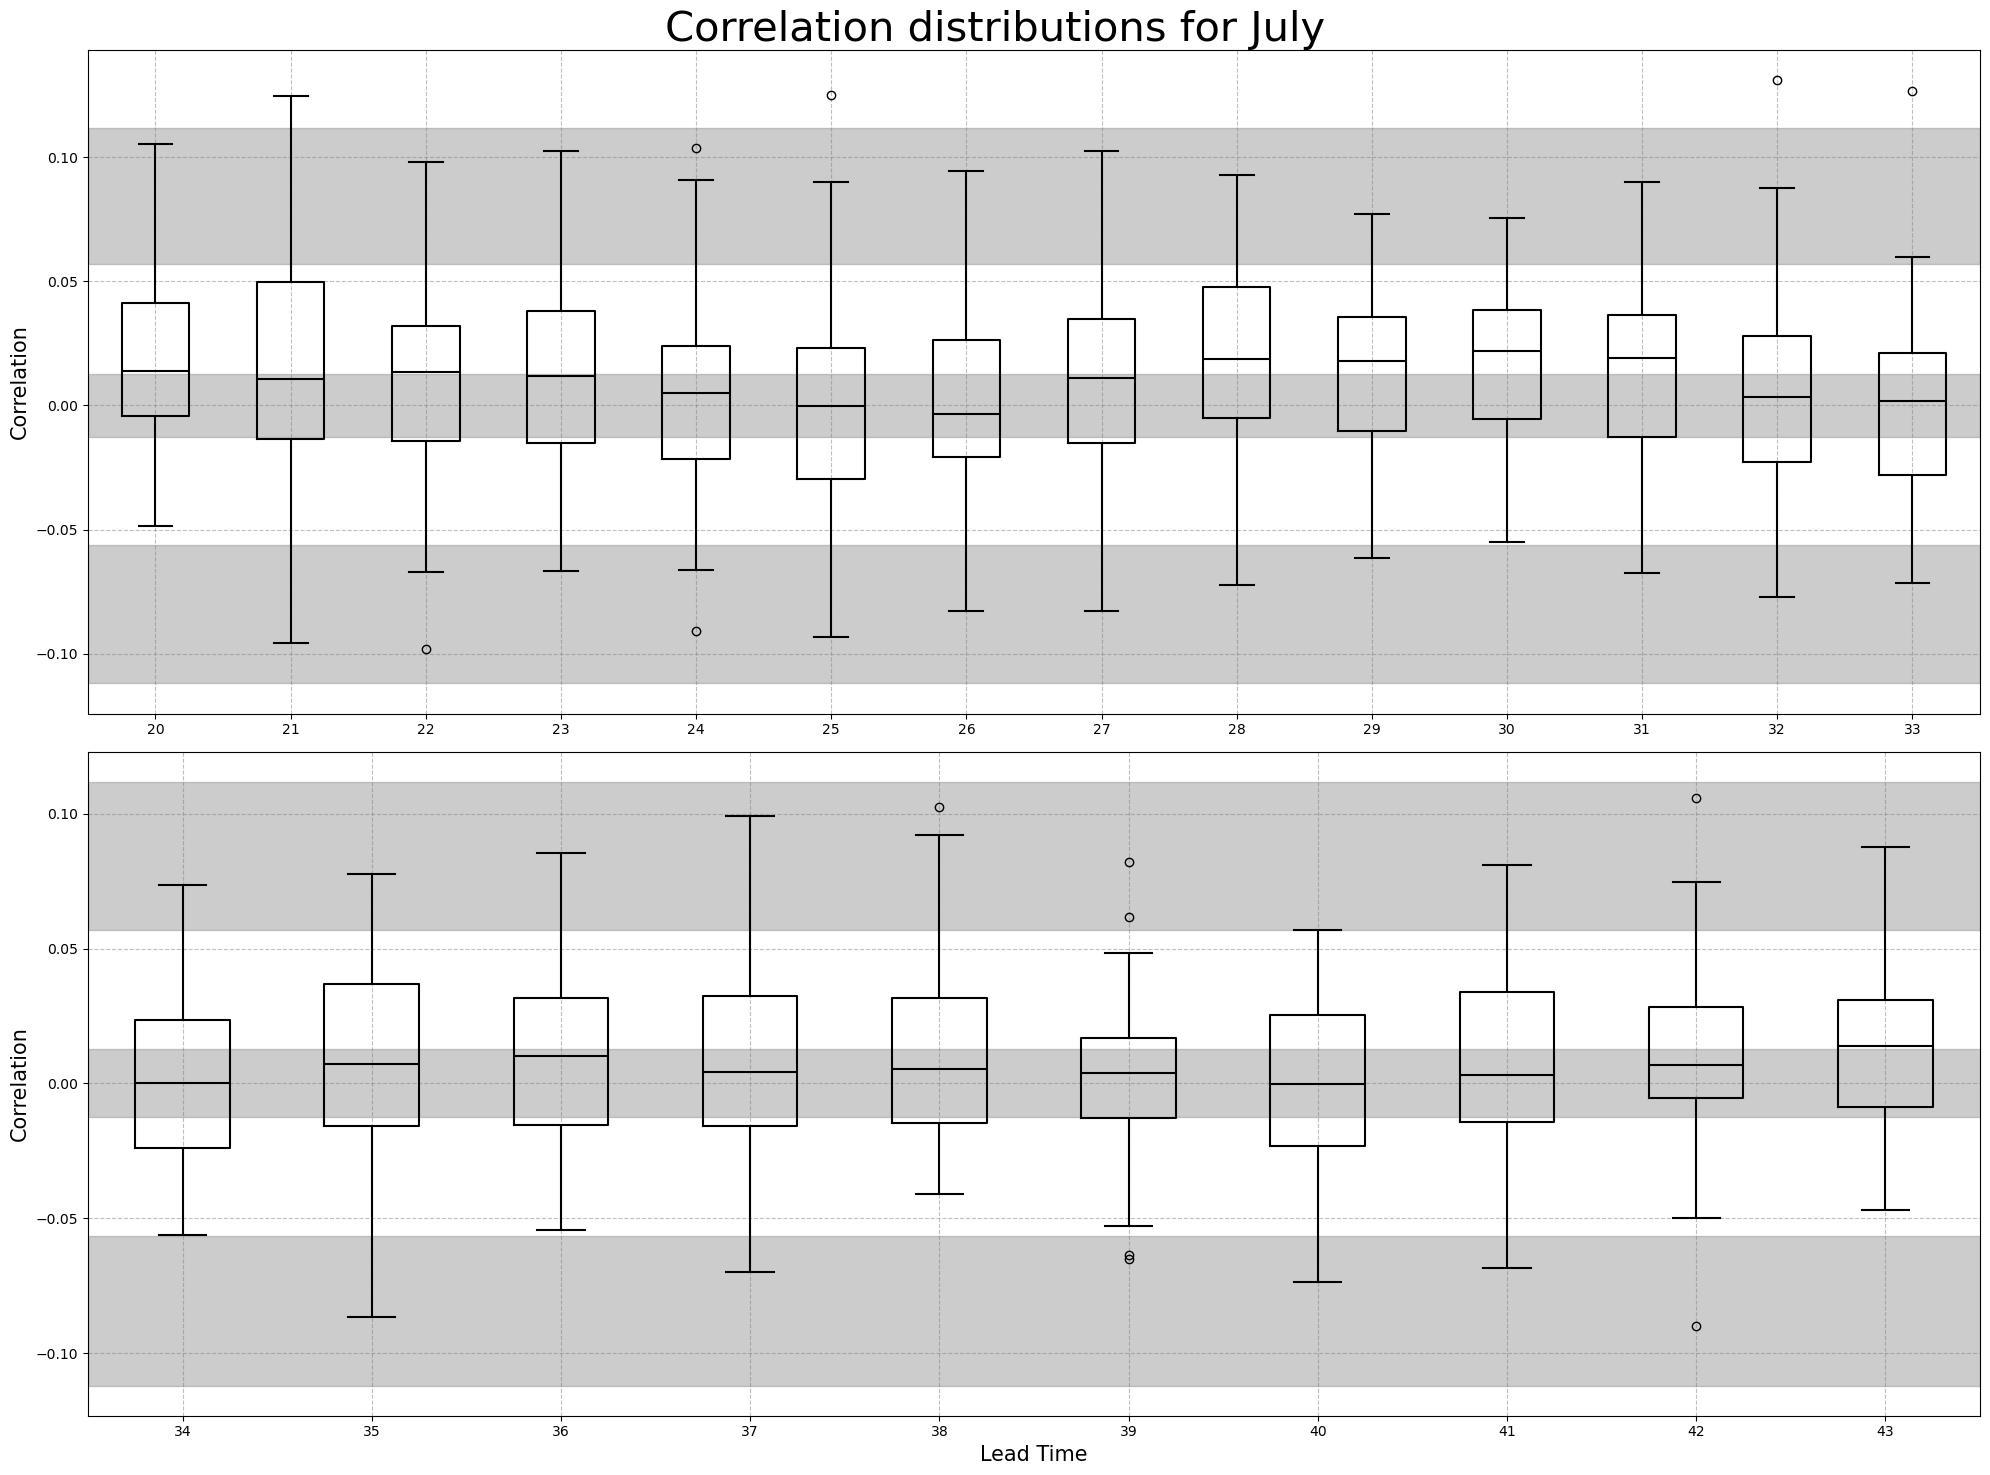

In [21]:
corr, interv = ind.correlation(corrected_2)
ind.plot_correlations(corr, interv, "", show=True)